In [1]:
import h5py
import numpy as np
from scipy.io import loadmat
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from scipy.ndimage import gaussian_filter1d

In [2]:
def downsample_mean(X, factor):
    n_trials, time_len, n_channels, n_sources = X.shape
    cut_len = (time_len // factor) * factor
    X = X[:, :cut_len, :, :]
    print(X.shape)
    X = X.reshape(n_trials, cut_len // factor, factor, n_channels, n_sources)
    print(X.shape)
    return X.mean(axis=2) 
      
def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):
    """
    Parameters
    ----------
    X : array, shape (N, T, C, F)
    MUA : array, shape (N, T, C, F)
    y : array, shape (N,)
    sessions : array, shape (N,)
    groups : list of lists
    position_indices : list of ints
    selected_within_group : list of ints
    condition_label : int
    t_min, t_max : float
        Epoch time limits (seconds)
    baseline_window : tuple (start, end)
        Baseline interval in seconds
    downsample_factor : int or None
    """

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :, 3:4]

    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    if downsample_factor is not None:
        X_combined = downsample_mean(X_combined, downsample_factor)

    return X_combined, y_local, y_condition, session_subset

def compute_scaled_values(X, y, freq_indices, t_start, t_end):
    """
    Возвращает усреднённые и std значения по каналам для указанного временного окна.
    freq_indices: int или list/array индексов частот
    """
    if isinstance(freq_indices, int):
        freq_indices = [freq_indices]

    time_mask = (times >= t_start) & (times <= t_end)
    time_indices = np.where(time_mask)[0]

    mean_per_pos_chan = []
    for pos in positions:
        trials_pos = X[y == pos, :, :, :]  # trials × time × channels × freqs
        # усреднение по времени и выбранным частотам
        trials_time_avg = trials_pos[:, time_indices, :, :][:, :, :, freq_indices].mean(axis=1)  # trials × channels × freqs
        trials_freq_avg = trials_time_avg.mean(axis=-1)  # усреднение по выбранным частотам → trials × channels
        mean_channels = trials_freq_avg.mean(axis=0)    # среднее по трайлам для каждого канала
        mean_per_pos_chan.append(mean_channels)
    
    mean_per_pos_chan = np.array(mean_per_pos_chan)  # positions × channels

    # центрирование по каналам
    mean_centered = mean_per_pos_chan - mean_per_pos_chan.mean(axis=0, keepdims=True)

    # масштабирование к [-1, 1]
    min_vals = mean_centered.min(axis=0, keepdims=True)
    max_vals = mean_centered.max(axis=0, keepdims=True)
    mean_scaled = 2 * (mean_centered - min_vals) / (max_vals - min_vals) - 1

    # усреднение по каналам
    mean_avg = mean_scaled.mean(axis=1)
    std_avg = mean_scaled.std(axis=1)
    return mean_avg, std_avg

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / dof)
    return (x.mean() - y.mean()) / pooled_std

def plot_left_block(fig, outer_spec, results, positions, time_windows):

    left = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer_spec,
        hspace=0.35,
        wspace=0.25
    )

    axes = [fig.add_subplot(left[i, j]) for i in range(2) for j in range(2)]

    # =====================================================
    # 9 Hz (верхний ряд)
    # =====================================================

    for idx, ((t_start, t_end), ax) in enumerate(zip(time_windows, axes[:2])):

        mean_9  = results["mean_9hz"][idx]
        std_9   = results["std_9hz"][idx]
        mean_mua = results["mean_mua"][idx]
        std_mua  = results["std_mua"][idx]

        r      = results["corrs9hz"][idx]
        p_corr = results["pvals_corrected9hz"][idx]
        sig    = results["reject9hz"][idx]

        ax.axvspan(8.0, 14.5, color="lightgray", alpha=0.3)
        for pos in [7.5, 15]:
            ax.axvspan(pos - 0.5, pos + 1,
                       color="gray", alpha=0.3, hatch="///")

        ax.plot(positions, mean_9, color="tab:blue", linewidth=2)
        ax.fill_between(positions,
                        mean_9 - std_9,
                        mean_9 + std_9,
                        color="tab:blue", alpha=0.2)

        ax.plot(positions, mean_mua, color="tab:orange", linewidth=2)
        ax.fill_between(positions,
                        mean_mua - std_mua,
                        mean_mua + std_mua,
                        color="tab:orange", alpha=0.2)

        sig_marker = "*" if sig else "ns"
        #ax.set_title(
        #    f"{t_start:.2f}-{t_end:.2f}s\n"
        #    f"9 Hz r={r:.2f}, p={p_corr:.3f} {sig_marker}",
        #    fontsize=9
        #)

        ax.set_title(
            f"MUA and 9 Hz by positions \n"
            f"{t_start:.2f}-{t_end:.2f}s, r={r:.2f}",
            fontsize=11
        )
        ax.grid(False)

    # =====================================================
    # 25 Hz (нижний ряд)
    # =====================================================

    for idx, ((t_start, t_end), ax) in enumerate(zip(time_windows, axes[2:])):

        mean_25 = results["mean_25hz"][idx]
        std_25  = results["std_25hz"][idx]
        mean_mua = results["mean_mua"][idx]
        std_mua  = results["std_mua"][idx]

        r      = results["corrs25hz"][idx]
        p_corr = results["pvals_corrected25hz"][idx]
        sig    = results["reject25hz"][idx]

        ax.axvspan(8.0, 14.5, color="lightgray", alpha=0.3)
        for pos in [7.5, 15]:
            ax.axvspan(pos - 0.5, pos + 1,
                       color="gray", alpha=0.3, hatch="///")

        ax.plot(positions, mean_25,
                color="tab:blue", linestyle="--", linewidth=2)
        ax.fill_between(positions,
                        mean_25 - std_25,
                        mean_25 + std_25,
                        color="tab:blue", alpha=0.2)

        ax.plot(positions, mean_mua, color="tab:orange", linewidth=2)
        ax.fill_between(positions,
                        mean_mua - std_mua,
                        mean_mua + std_mua,
                        color="tab:orange", alpha=0.2)

        sig_marker = "*" if sig else "ns"
        #ax.set_title(
        #    f"{t_start:.2f}-{t_end:.2f}s\n"
        #    f"25 Hz r={r:.2f}, p={p_corr:.3f} {sig_marker}",
        #    fontsize=9
        #)
        ax.set_title(
            f"MUA and 25 Hz by positions \n"
            f"{t_start:.2f}-{t_end:.2f}s, r={r:.2f}",
            fontsize=11
        )
        ax.grid(False)

    # =====================================================
    # Убираем X-ось ЖЁСТКО (в самом конце)
    # =====================================================


    for ax in axes:
        ax.set_xticklabels([])           # убрать числа
        ax.tick_params(axis='x', length=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes:
        ax.set_xlabel("Figure", fontsize=10)

    axes[0].set_ylabel("Scaled value")
    axes[2].set_ylabel("Scaled value")

    return axes

In [3]:
data = loadmat('C:/Users/Danila/Downloads/X_and_y_all_Bobo.mat')  #X_and_y_all_curveBobo
with h5py.File('C:/Users/Danila/monkey_current/X_all_figureBoboV1_power_ALL_FREQS_onlyTFR_baseline.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 
y_all = data['y_all'].squeeze()
Mua = data['X_all']
# Удалим NaN
mask = ~np.isnan(y_all)
n1, n2, n3 = 1774, 1512, 1366

session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int),
    np.full(n3, 2, dtype=int)
])

#print(X_all.shape)
#X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
Mua = Mua[mask]
session_ids_clean = session_ids[mask]


groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]

['X_all']


In [4]:
positions = list(range(0, 23)) #0-12, 12-23

X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

In [5]:
distances = np.array([
    -5.4064636817277, -4.9130019973084, -4.41954031288911,
    -3.92607862846982, -3.43261694405053, -2.93915525963124,
    -2.44569357521195, -1.95223189079266, -1.45877020637337,
    -0.965308521954082, -0.471846837534792, 0.021614846884499,
     0.515076531303789,  1.00853821572308, 1.50199990014237,
     1.99546158456166,  2.48892326898095, 2.98238495340024,
     3.47584663781953,  3.96930832223882,  4.46277000665811,
     4.9562316910774,  5.44969337549669
])

In [6]:
# примеры индексов частот
idx_9hz = 4
idx_mua = -1

t_min, t_max = -0.2, 0.6
n_time = X.shape[1]
times = np.linspace(t_min, t_max, n_time)

positions = np.unique(y)  # 23 позиции

# список временных интервалов
time_windows = [
    (0.1, 0.15), (0.35, 0.5)
]
results = {
    "mean_9hz": [],
    "mean_25hz": [],
    "std_9hz": [],
    "std_25hz": [],
    "mean_mua": [],
    "std_mua": [],
    "corrs9hz": [],
    "pvals9hz": [],
    "pvals_corrected9hz": [],
    "reject9hz": [],
    "corrs25hz": [],
    "pvals25hz": [],
    "pvals_corrected25hz": [],
    "reject25hz": []
}
corrs, pvals = [], []
for (t_start, t_end) in time_windows:
    
    mean_9hz_avg, std_9hz_avg = compute_scaled_values(
        X, y, freq_indices=[idx_9hz], t_start=t_start, t_end=t_end
    )
    
    mean_mua_avg, std_mua_avg = compute_scaled_values(
        X, y, freq_indices=idx_mua, t_start=t_start, t_end=t_end
    )
    
    corr, pval = pearsonr(mean_9hz_avg, mean_mua_avg)

    # сохраняем
    results["mean_9hz"].append(mean_9hz_avg)
    results["std_9hz"].append(std_9hz_avg)
    results["mean_mua"].append(mean_mua_avg)
    results["std_mua"].append(std_mua_avg)
    results["corrs9hz"].append(corr)
    results["pvals9hz"].append(pval)


reject, pvals_corrected, _, _ = multipletests(
    results["pvals9hz"], alpha=0.05, method="fdr_bh"
)

results["pvals_corrected9hz"] = pvals_corrected
results["reject9hz"] = reject

In [7]:
idx_9hz = -2

corrs, pvals = [], []
for (t_start, t_end) in time_windows:
    
    mean_9hz_avg, std_9hz_avg = compute_scaled_values(
        X, y, freq_indices=[idx_9hz], t_start=t_start, t_end=t_end
    )
    
    mean_mua_avg, std_mua_avg = compute_scaled_values(
        X, y, freq_indices=idx_mua, t_start=t_start, t_end=t_end
    )
    
    corr, pval = pearsonr(mean_9hz_avg, mean_mua_avg)

    # сохраняем
    results["mean_25hz"].append(mean_9hz_avg)
    results["std_25hz"].append(std_9hz_avg)
    results["corrs25hz"].append(corr)
    results["pvals25hz"].append(pval)

# --- коррекция на множественные сравнения (Bonferroni или FDR) ---

reject, pvals_corrected, _, _ = multipletests(
    results["pvals25hz"], alpha=0.05, method="fdr_bh"
)

results["pvals_corrected25hz"] = pvals_corrected
results["reject25hz"] = reject

In [ ]:
Add In only 

In [8]:
positions = list(range(8, 14)) #0-12, 12-23

X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

In [9]:
high_alpha_trials = {}
low_alpha_trials = {}

mean_low_windows = []
mean_high_windows = []
# --- Параметры ---
freq_9_idx = 4
mua_idx = -1

t_start, t_end = -0.2, 0.6
n_time = X.shape[1]
time_centers = np.linspace(t_start, t_end, n_time)

window_size = 0.05
step = 0.05

# --- Данные ---
lf8_data = X[:, :, :, freq_9_idx]
mua_data = X[:, :, :, mua_idx]

mua_smooth = gaussian_filter1d(mua_data, sigma=2, axis=1)

# --- Окна ---
windows = []
t = 0.0
while t + window_size <= t_end:
    windows.append((t, t + window_size))
    t += step

mua_low_all = []
mua_high_all = []
pvals = []
effects9 = []

for (t1, t2) in windows:
    
    mask = (time_centers >= t1) & (time_centers < t2)
    
    # --- Альфа в этом окне ---
    lf8_avg = lf8_data[:, mask, :].mean(axis=1).mean(axis=1)
    
    q20, q80 = np.percentile(lf8_avg, [20, 80])
    low_idx = np.where(lf8_avg <= q20)[0]
    high_idx = np.where(lf8_avg >= q80)[0]

    window_key = (round(t1, 3), round(t2, 3))

    high_alpha_trials[window_key] = high_idx
    low_alpha_trials[window_key] = low_idx
    
    # --- MUA в этом же окне ---
    mua_low = mua_smooth[low_idx][:, mask, :].mean(axis=2).mean(axis=1)
    mua_high = mua_smooth[high_idx][:, mask, :].mean(axis=2).mean(axis=1)

    if np.isclose(t1, 0.10) and np.isclose(t2, 0.15):
        alpha_window_low = mua_low.copy()
        alpha_window_high = mua_high.copy()
        print("\nSaved window 0.10–0.15")
        print(f"Low mean  = {alpha_window_low.mean():.6e}")
        print(f"High mean = {alpha_window_high.mean():.6e}")

         
    # --- Средние по окну ---
    mean_low = np.mean(mua_low)
    mean_high = np.mean(mua_high)
    
    mean_low_windows.append(mean_low)
    mean_high_windows.append(mean_high)
    
    # сохраняем кривые (для общей формы)
    mua_low_all.append(mua_smooth[low_idx].mean(axis=2).mean(axis=0))
    mua_high_all.append(mua_smooth[high_idx].mean(axis=2).mean(axis=0))
    
    # t-test
    t_stat, p_two = ttest_ind(mua_low, mua_high, equal_var=True)
    
    if t_stat > 0:
        p_val = p_two / 2
    else:
        p_val = 1 - (p_two / 2)
    
    d_val = cohens_d(mua_low, mua_high)
    
    pvals.append(p_val)
    effects9.append(d_val)

# --- FDR ---
reject9, pvals_corr = fdrcorrection(pvals, alpha=0.05)

# --- Итоговые кривые ---
mua_low_final9 = np.mean(mua_low_all, axis=0)
mua_high_final9 = np.mean(mua_high_all, axis=0)


Saved window 0.10–0.15
Low mean  = 7.961475e-06
High mean = 3.266676e-06


In [10]:
freq_25_idx = -2
mua_idx = -1

t_start, t_end = -0.2, 0.6
n_time = X.shape[1]
time_centers = np.linspace(t_start, t_end, n_time)

window_size = 0.05
step = 0.05

# --- Данные ---
lf8_data = X[:, :, :, freq_25_idx]
mua_data = X[:, :, :, mua_idx]

high_beta_trials = {}
low_beta_trials = {}

mua_smooth = gaussian_filter1d(mua_data, sigma=2, axis=1)

# --- Окна ---
windows = []
t = 0.0
while t + window_size <= t_end:
    windows.append((t, t + window_size))
    t += step

mua_low_all = []
mua_high_all = []
pvals = []
effects25 = []

for (t1, t2) in windows:
    
    mask = (time_centers >= t1) & (time_centers < t2)
    
    # --- Альфа в этом окне ---
    lf8_avg = lf8_data[:, mask, :].mean(axis=1).mean(axis=1)
    
    q20, q80 = np.percentile(lf8_avg, [20, 80])
    low_idx = np.where(lf8_avg <= q20)[0]
    high_idx = np.where(lf8_avg >= q80)[0]

    window_key = (round(t1, 3), round(t2, 3))

    high_beta_trials[window_key] = high_idx
    low_beta_trials[window_key] = low_idx
    
    # --- MUA в этом же окне ---
    mua_low = mua_smooth[low_idx][:, mask, :].mean(axis=2).mean(axis=1)
    mua_high = mua_smooth[high_idx][:, mask, :].mean(axis=2).mean(axis=1)

    if np.isclose(t1, 0.10) and np.isclose(t2, 0.15):
        beta_window_low = mua_low.copy()
        beta_window_high = mua_high.copy()
        print("\nSaved window 0.10–0.15")
        print(f"Low mean  = {alpha_window_low.mean():.6e}")
        print(f"High mean = {alpha_window_high.mean():.6e}")
    
    # сохраняем кривые (для общей формы)
    mua_low_all.append(mua_smooth[low_idx].mean(axis=2).mean(axis=0))
    mua_high_all.append(mua_smooth[high_idx].mean(axis=2).mean(axis=0))
    
    # t-test

    t_stat, p_two = ttest_ind(mua_low, mua_high, equal_var=True)
    
    if t_stat > 0:
        p_val = p_two / 2
    else:
        p_val = 1 - (p_two / 2)
    
    d_val = cohens_d(mua_low, mua_high)
    
    pvals.append(p_val)
    effects25.append(d_val)

# --- FDR ---
reject25, pvals_corr = fdrcorrection(pvals, alpha=0.05)

# --- Итоговые кривые ---
mua_low_final25 = np.mean(mua_low_all, axis=0)
mua_high_final25 = np.mean(mua_high_all, axis=0)


Saved window 0.10–0.15
Low mean  = 7.961475e-06
High mean = 3.266676e-06


In [11]:
results_longcurves = {
    "alpha_window_low": [],
    "alpha_window_high": [],
    "beta_window_low": [],
    "beta_window_high": [],
    "mua_high_final9": [],
    "mua_low_final9": [],
    "reject9": [],
    "mua_high_final25": [],
    "mua_low_final25": [],
    "reject25": [],
    "effects25": [],
    "effects9": [],
    "time_centers" : []
}

In [12]:
results_longcurves["alpha_window_low"].append(alpha_window_low)
results_longcurves["alpha_window_high"].append(alpha_window_high)
results_longcurves["beta_window_low"].append(beta_window_low)
results_longcurves["beta_window_high"].append(beta_window_high)

results_longcurves["mua_high_final9"].append(mua_high_final9)
results_longcurves["mua_low_final9"].append(mua_low_final9)
results_longcurves["reject9"].append(reject9)
results_longcurves["mua_high_final25"].append(mua_high_final25)
results_longcurves["mua_low_final25"].append(mua_low_final25)
results_longcurves["reject25"].append(reject25)
results_longcurves["effects25"].append(effects25)
results_longcurves["effects9"].append(effects9)
results_longcurves["time_centers"].append(time_centers)


In [13]:
import numpy as np

save_dict = {

    # --- основные результаты корреляций ---
    "mean_9hz": results["mean_9hz"],
    "std_9hz": results["std_9hz"],
    "mean_25hz": results["mean_25hz"],
    "std_25hz": results["std_25hz"],
    "mean_mua": results["mean_mua"],
    "std_mua": results["std_mua"],

    "corrs9hz": results["corrs9hz"],
    "pvals9hz": results["pvals9hz"],
    "pvals_corrected9hz": results["pvals_corrected9hz"],
    "reject9hz": results["reject9hz"],

    "corrs25hz": results["corrs25hz"],
    "pvals25hz": results["pvals25hz"],
    "pvals_corrected25hz": results["pvals_corrected25hz"],
    "reject25hz": results["reject25hz"],

    # --- временные оси ---
    "time_centers": time_centers,
    "positions": positions,
    "time_windows": np.array(time_windows, dtype=object),

    # --- MUA conditioning ---
    "mua_low_final9": mua_low_final9,
    "mua_high_final9": mua_high_final9,
    "mua_low_final25": mua_low_final25,
    "mua_high_final25": mua_high_final25,

    # --- окна значимости ---
    "windows": np.array(windows, dtype=object),

}

np.savez("M1_all_figure2_data.npz", **save_dict)
print("Saved to M1_all_figure_data.npz")


Saved to M1_all_figure_data.npz


In [14]:
save_dict = {

    # --- основные результаты корреляций ---
    "high_alpha_trials": high_alpha_trials,
    "high_beta_trials ": high_beta_trials ,
}
np.savez("M1_all_figure2_trialforphase.npz", **save_dict)

In [ ]:
Phase 

In [15]:
import h5py
from scipy.io import loadmat
import numpy as np

#C:/Users/Danila/Downloads/X_all_figureBoboV1_phase_ALL_FREQS_onlyTFR_baseline_evokedsubs.mat'
#old X_all_figureJosefV1_power_ALL_FREQS_onlyTFR.mat new X_all_figureJosefV1_power_ALL_FREQS_onlyTFR_baseline  X_all_curveBoboV1_power_ALL_FREQS_onlyTFR_baseline
# X_and_y_all_Bobo  X_and_y_all_figureBoboV4  X_and_y_all_curveJosef  X_and_y_all_curveBobo
data = loadmat('C:/Users/Danila/Downloads/X_and_y_all_Bobo.mat')
with h5py.File('C:/Users/Danila/monkey_current/X_all_figureBoboV1_phase_ALL_FREQS_onlyTFR.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 
y_all = data['y_all'].squeeze()
Mua = data['X_all']
# Удалим NaN
mask = ~np.isnan(y_all)
#print(X_all.shape)
#X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
Mua = Mua[mask]


groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]

#groups = [
#    [1,2,47,48], [3,4,49,50], [5,6,51,52], [7,8,53,54], [9,10,55,56], 
#    [11,12,57,58], [13,14,59,60], [15,16,61,62], [17,18,63,64], 
#    [19,20,65,66], [21,22,67,68], [23,24,69,70], [25,26,71,72], 
#    [27,28,73,74], [29,30,75,76], [31,32,77,78], [33,34,79,80], 
#    [35,36,81,82], [37,38,83,84], [39,40,85,86], [41,42,87,88], 
#    [43,44,89,90], [45,46,91,92]
#]

# for phase
order_per_freq = np.zeros(21, dtype=int)
order_per_freq[0:4] = 2    # Freq 0–3
order_per_freq[4:10] = 3   # Freq 4–9
order_per_freq[10:17] = 4  # Freq 10–16
order_per_freq[17:21] = 5  # Freq 17–20

corrected_phase = np.empty_like(X_clean)

# --- Домножаем по каждой частоте ---
for i_f, k in enumerate(order_per_freq):
    corrected_phase[:, :, :, i_f] = X_clean[:, :, :, i_f] * k

X_clean = corrected_phase

['X_all']


In [16]:
def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):
    """
    Parameters
    ----------
    X : array, shape (N, T, C, F)
    MUA : array, shape (N, T, C, F)
    y : array, shape (N,)
    sessions : array, shape (N,)
    groups : list of lists
    position_indices : list of ints
    selected_within_group : list of ints
    condition_label : int
    t_min, t_max : float
        Epoch time limits (seconds)
    baseline_window : tuple (start, end)
        Baseline interval in seconds
    downsample_factor : int or None
    """

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :, 3:4]

    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    #if downsample_factor is not None:
    #    X_combined = downsample_mean(X_combined, downsample_factor)

    return X_combined, y_local, y_condition, session_subset

In [17]:
# внутри каждой позиции оставляем только 0-й и 2-й элемент группы (1-й и 3-й по original)
positions = list(range(8, 14)) #0-12, 12-23

X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

In [18]:
data_window = X[:, t_mask, :, 4]  
# shape: trials × time × channels
print("GLOBAL MIN:", np.min(data_window))
print("GLOBAL MAX:", np.max(data_window))

NameError: name 't_mask' is not defined

In [19]:
n_bins = 18
phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
phase_centers = (phase_bins[:-1] + phase_bins[1:]) / 2

H_uniform = np.log(n_bins)

n_permutations = 1000
eps = 1e-12

t_windows = [(0.1, 0.15), (0.4, 0.45)]
freqs = {"9Hz": 4, "25Hz": -2}

mua_idx = -1
n_channels = X.shape[2]

# =====================================================
# РЕЗУЛЬТАТЫ
# =====================================================
phase_mua_results = {}
mua_binned_channels = np.full((n_channels, n_bins), np.nan)

# =====================================================
# ОСНОВНОЙ ЦИКЛ
# =====================================================
for freq_name, freq_idx in freqs.items():

    phase_mua_results[freq_name] = {}

    trial_dict = high_alpha_trials if freq_name == "9Hz" else high_beta_trials

    for t_win in t_windows:

        selected_trials = trial_dict[t_win]

        t_min, t_max = t_win
        t_mask = (times >= t_min) & (times <= t_max)

        window_key = f"{t_min:.2f}-{t_max:.2f}"

        # =====================================================
        # ВЫБОР ДАННЫХ
        # =====================================================
        X_sel = X[selected_trials]

        X_freq = X_sel[:, :, :, freq_idx]
        X_mua = X_sel[:, :, :, mua_idx]

        phase_all = X_freq[:, t_mask, :]
        mua_all = X_mua[:, t_mask, :]

        n_trials, n_time, n_channels = phase_all.shape

        print(freq_name, window_key)
        print("phase shape:", phase_all.shape)
        print("mua shape:", mua_all.shape)

        # =====================================================
        # КОНТЕЙНЕРЫ
        # =====================================================
        MI_obs = np.full(n_channels, np.nan)
        MI_perm = np.full((n_channels, n_permutations), np.nan)

        # =====================================================
        # ЦИКЛ ПО КАНАЛАМ
        # =====================================================
        for ch in range(n_channels):

            phase_ch = phase_all[:, :, ch]
            mua_ch = mua_all[:, :, ch]

            phase_values = phase_ch.flatten()
            mua_values = mua_ch.flatten()

            # =====================================================
            # ПРОВЕРКА ФАЗОВЫХ БИНОВ
            # =====================================================
            counts, _ = np.histogram(phase_values, bins=phase_bins)

            if np.any(counts == 0):
                print(f"Skip channel {ch} (empty phase bins)")
                continue

            # =====================================================
            # PHASE BINNING
            # =====================================================
            mua_binned = np.zeros(n_bins)

            for i in range(n_bins):

                mask = (
                    (phase_values >= phase_bins[i]) &
                    (phase_values < phase_bins[i + 1])
                )

                mua_binned[i] = np.mean(mua_values[mask])

            # =====================================================
            # MI OBSERVED
            # =====================================================
            p = mua_binned / (np.sum(mua_binned) + eps)

            H_obs = -np.sum(p * np.log(p + eps))

            MI_obs[ch] = (H_uniform - H_obs) / H_uniform
            mua_binned_channels[ch] = mua_binned
            # =====================================================
            # PERMUTATIONS
            # =====================================================
            for k in range(n_permutations):

                mua_shuffled = np.random.permutation(mua_values)

                mua_binned_perm = np.zeros(n_bins)

                for i in range(n_bins):

                    mask = (
                        (phase_values >= phase_bins[i]) &
                        (phase_values < phase_bins[i + 1])
                    )

                    mua_binned_perm[i] = np.mean(mua_shuffled[mask])

                p_perm = mua_binned_perm / (np.sum(mua_binned_perm) + eps)

                H_perm = -np.sum(p_perm * np.log(p_perm + eps))

                MI_perm[ch, k] = (H_uniform - H_perm) / H_uniform

        # =====================================================
        # P-VALUES ПО КАНАЛАМ
        # =====================================================
        p_values = np.full(n_channels, np.nan)

        for ch in range(n_channels):

            if not np.isnan(MI_obs[ch]):

                p_values[ch] = np.mean(
                    MI_perm[ch] >= MI_obs[ch]
                )

        # =====================================================
        # POPULATION MI
        # =====================================================
        mean_MI_obs = np.nanmean(MI_obs)

        mean_MI_perm_channels = np.nanmean(MI_perm, axis=0)

        valid_perm = ~np.isnan(mean_MI_perm_channels)

        if np.any(valid_perm):

            p_population = np.mean(
                mean_MI_perm_channels[valid_perm] >= mean_MI_obs
            )

        else:

            p_population = np.nan
            
        mean_mua_binned = np.nanmean(mua_binned_channels, axis=0)

        mua_percent = (
            (mean_mua_binned - np.mean(mean_mua_binned))
            / np.mean(mean_mua_binned)
        ) * 100

        # =====================================================
        # СОХРАНЕНИЕ
        # =====================================================
        phase_mua_results[freq_name][window_key] = {

            "phase_bins": phase_bins,
            "phase_centers": phase_centers,

            "MI_obs": MI_obs,
            "MI_perm": MI_perm,

            "mean_MI_obs": mean_MI_obs,
            "mean_MI_perm": mean_MI_perm_channels,

            "p_population": p_population,
            "p_values": p_values,
            "mua_percent": mua_percent,
            "mua_binned": mean_mua_binned,

            "selected_trials": selected_trials
        }

print("✓ Phase–MUA MI computation done.")

# =====================================================
# СОХРАНЕНИЕ НА ДИСК
# =====================================================
np.savez(
    "Phase_MUA_MI_results.npz",
    phase_mua_results=phase_mua_results
)

print("Saved to Phase_MUA_MI_results.npz")

9Hz 0.10-0.15
phase shape: (239, 38, 18)
mua shape: (239, 38, 18)


C:\Users\Danila\AppData\Local\Temp\ipykernel_18332\2405536397.py:102: RuntimeWarning: invalid value encountered in log
  H_obs = -np.sum(p * np.log(p + eps))
C:\Users\Danila\AppData\Local\Temp\ipykernel_18332\2405536397.py:126: RuntimeWarning: invalid value encountered in log
  H_perm = -np.sum(p_perm * np.log(p_perm + eps))


9Hz 0.40-0.45
phase shape: (239, 38, 18)
mua shape: (239, 38, 18)
25Hz 0.10-0.15
phase shape: (239, 38, 18)
mua shape: (239, 38, 18)
25Hz 0.40-0.45
phase shape: (239, 38, 18)
mua shape: (239, 38, 18)
✓ Phase–MUA MI computation done.
Saved to Phase_MUA_MI_results.npz


In [34]:
for freq_name, windows in phase_mua_results.items():

    print(f"\n===== {freq_name} =====")

    for window_key, res in windows.items():

        MI = res["mean_MI_obs"]
        p  = res["p_population"]

        print(f"{window_key}: MI = {MI:.4f}, p = {p:.4g}")


===== 9Hz =====
0.10-0.15: MI = 0.0259, p = 0
0.40-0.45: MI = 0.0030, p = 0.034

===== 25Hz =====
0.10-0.15: MI = 0.0054, p = 0.684
0.40-0.45: MI = 0.0068, p = 0.219


In [20]:
import numpy as np

# =========================
# Load saved figure data
# =========================

data = np.load("M1_all_figure2_data.npz", allow_pickle=True)

# --- корреляции ---
mean_9hz = data["mean_9hz"]
std_9hz = data["std_9hz"]
mean_25hz = data["mean_25hz"]
std_25hz = data["std_25hz"]
mean_mua = data["mean_mua"]
std_mua = data["std_mua"]

corrs9hz = data["corrs9hz"]
pvals9hz = data["pvals9hz"]
pvals_corrected9hz = data["pvals_corrected9hz"]
reject9hz = data["reject9hz"]

corrs25hz = data["corrs25hz"]
pvals25hz = data["pvals25hz"]
pvals_corrected25hz = data["pvals_corrected25hz"]
reject25hz = data["reject25hz"]

# --- временные оси ---
time_centers = data["time_centers"]
positions = data["positions"]
time_windows = data["time_windows"]

# --- conditioning кривые ---
mua_low_final9 = data["mua_low_final9"]
mua_high_final9 = data["mua_high_final9"]
mua_low_final25 = data["mua_low_final25"]
mua_high_final25 = data["mua_high_final25"]

# --- окна значимости ---
windows = data["windows"]

print("All data successfully loaded.")

All data successfully loaded.


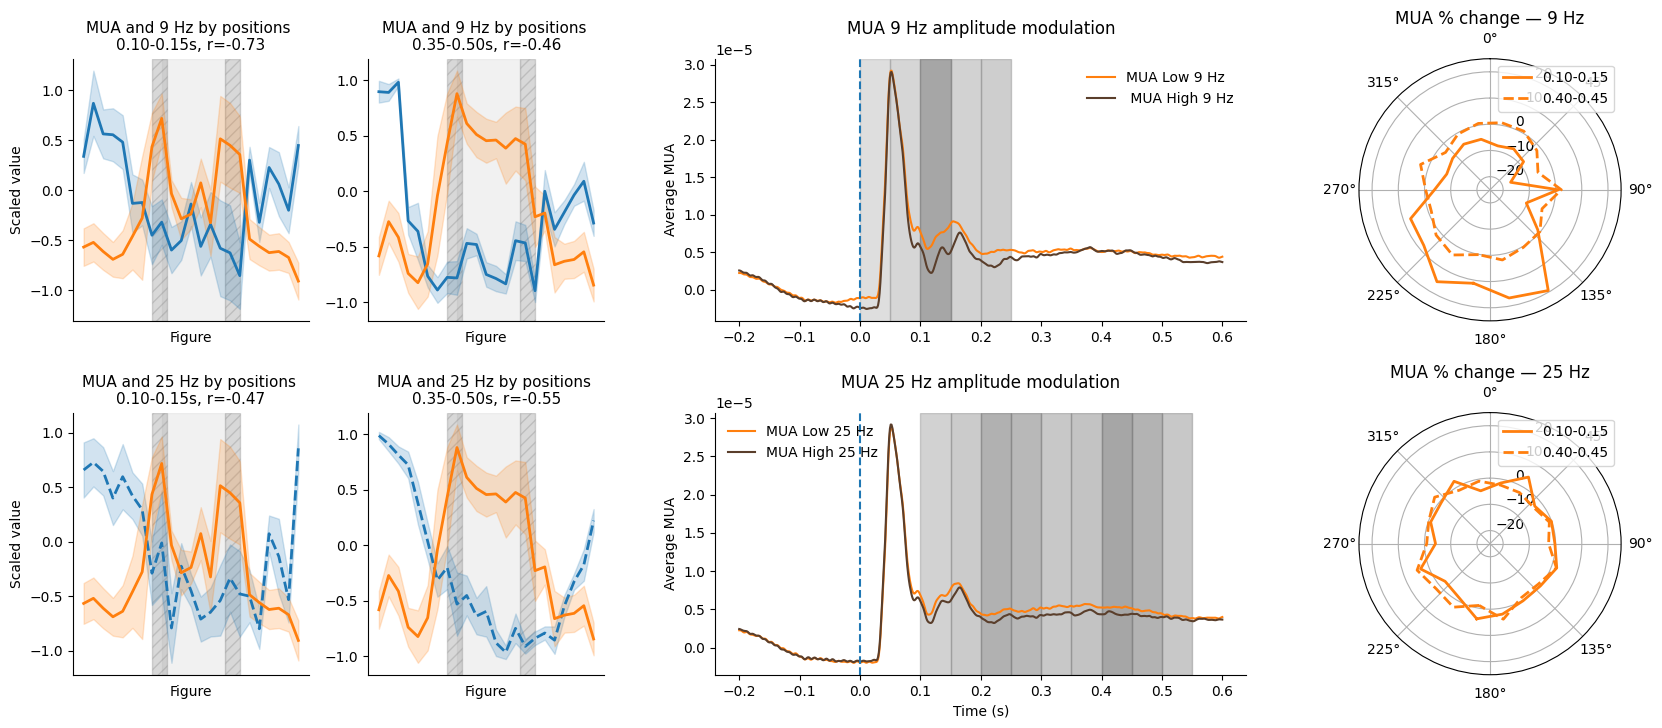

In [24]:
# =====================================================
# FIGURE GEOMETRY (СТРОГО ВЫРОВНЕННАЯ)
# =====================================================
positions = list(range(0, 23))
fig = plt.figure(figsize=(20, 8))  # КРИТИЧНО

outer = gridspec.GridSpec(
    2, 3,
    width_ratios=[2, 2, 1],  # математика
    height_ratios=[1, 1],
    wspace=0.25,
    hspace=0.35
)

# =====================================================
# LEFT BLOCK (2x2 PERFECT SQUARES)
# =====================================================

left = gridspec.GridSpecFromSubplotSpec(
    2, 2,
    subplot_spec=outer[:, 0],
    hspace=0.35,
    wspace=0.3
)


# Заполняем их
plot_left_block(fig, outer[:, 0], results, positions, time_windows)


# =====================================================
# CENTER COLUMN — CONDITIONING
# =====================================================

ax_c9  = fig.add_subplot(outer[0, 1])
ax_c25 = fig.add_subplot(outer[1, 1])

# ----- 9 Hz -----
ax_c9.plot(time_centers, mua_low_final9, label="MUA Low 9 Hz", color="tab:orange")
ax_c9.plot(time_centers, mua_high_final9, label=" MUA High 9 Hz", color="#5A3E2B")

abs_effects9 = np.abs(effects9)
max_effect9 = np.nanmax(abs_effects9)

for d_val, sig, (t1, t2) in zip(effects9, reject9, windows):
    if sig == True:  # только значимые
        intensity = abs(d_val) / (max_effect9 + 1e-12)
        alpha_val = 0.1 + 0.6 * intensity  # минимальная прозрачность 0.1, максимальная 0.7
        ax_c9.axvspan(
            t1, t2,
            color="gray",
            alpha=alpha_val
        )

ax_c9.axvline(0, linestyle="--")
ax_c9.set_title("MUA 9 Hz amplitude modulation", pad=18)
ax_c9.set_ylabel("Average MUA")
ax_c9.legend(frameon=False)
ax_c9.grid(False)

# ----- 25 Hz -----
ax_c25.plot(time_centers, mua_low_final25, label="MUA Low 25 Hz", color="tab:orange")
ax_c25.plot(time_centers, mua_high_final25, label="MUA High 25 Hz", color="#5A3E2B")

abs_effects25 = np.abs(effects25)
max_effect25 = np.nanmax(abs_effects25)

for d_val, sig, (t1, t2) in zip(effects25, reject25, windows):
    if sig == True:  # только значимые
        intensity = abs(d_val) / (max_effect25 + 1e-12)
        alpha_val = 0.1 + 0.6 * intensity  # минимальная прозрачность 0.1, максимальная 0.7
        ax_c25.axvspan(
            t1, t2,
            color="gray",
            alpha=alpha_val
        )

ax_c25.axvline(0, linestyle="--")
ax_c25.set_title("MUA 25 Hz amplitude modulation", pad=18)
ax_c25.set_xlabel("Time (s)")
ax_c25.set_ylabel("Average MUA")
ax_c25.legend(frameon=False)
ax_c9.grid(False)


for ax in [ax_c9, ax_c25]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    
# =====================================================
# RIGHT COLUMN — % POLAR PLOTS
# =====================================================

ax_v9  = fig.add_subplot(outer[0, 2], projection='polar')
ax_v25 = fig.add_subplot(outer[1, 2], projection='polar')

# Цвета
early_color = "tab:orange"   # тот самый оранжевый
late_color  = "tab:orange"    # тот же цвет, но dash

# =====================================================
# 9 Hz
# =====================================================

windows_9 = list(phase_mua_results["9Hz"].keys())

for window_key in windows_9:

    res = phase_mua_results["9Hz"][window_key]

    phase_centers = res["phase_centers"]
    mua_binned    = res["mua_binned"]

    # % изменение
    mean_val = np.mean(mua_binned)
    mua_percent = ((mua_binned - mean_val) / (mean_val + 1e-12)) * 100

    # замыкание круга
    phase_plot = np.append(phase_centers, phase_centers[0])
    mua_plot   = np.append(mua_percent, mua_percent[0])

    # выбираем стиль по времени
    if window_key == windows_9[0]:   # первое окно = раннее
        ax_v9.plot(
            phase_plot,
            mua_plot,
            color=early_color,
            linewidth=2,
            label=f"{window_key}"
        )
    else:                            # второе окно = позднее
        ax_v9.plot(
            phase_plot,
            mua_plot,
            color=late_color,
            linestyle="--",
            linewidth=2,
            label=f"{window_key}"
        )

ax_v9.set_title("MUA % change — 9 Hz")

ax_v9.set_theta_zero_location("N")
ax_v9.set_theta_direction(-1)

ax_v9.set_ylim(-25, 25)

ax_v9.grid(True)
ax_v9.legend()


# =====================================================
# 25 Hz
# =====================================================

windows_25 = list(phase_mua_results["25Hz"].keys())

for window_key in windows_25:

    res = phase_mua_results["25Hz"][window_key]

    phase_centers = res["phase_centers"]
    mua_binned    = res["mua_binned"]

    mean_val = np.mean(mua_binned)
    mua_percent = ((mua_binned - mean_val) / (mean_val + 1e-12)) * 100

    phase_plot = np.append(phase_centers, phase_centers[0])
    mua_plot   = np.append(mua_percent, mua_percent[0])

    if window_key == windows_25[0]:
        ax_v25.plot(
            phase_plot,
            mua_plot,
            color=early_color,
            linewidth=2,
            label=f"{window_key}"
        )
    else:
        ax_v25.plot(
            phase_plot,
            mua_plot,
            color=late_color,
            linestyle="--",
            linewidth=2,
            label=f"{window_key}"
        )

ax_v25.set_title("MUA % change — 25 Hz")

ax_v25.set_theta_zero_location("N")
ax_v25.set_theta_direction(-1)

ax_v25.set_ylim(-25, 25)

ax_v25.grid(True)
ax_v25.legend()

plt.savefig("M1V1_Figure2polar.png", dpi=600)
plt.show()

In [27]:
corrs25hz

array([-0.47139296, -0.54930488])

In [28]:
pvals_corrected25hz

array([0.02316867, 0.01326212])

In [29]:
reject9

array([ True,  True,  True,  True,  True, False, False, False, False,
       False, False, False])

In [31]:
effects25

[np.float64(-0.23566059689660157),
 np.float64(-0.381104069430717),
 np.float64(0.2043968502237805),
 np.float64(0.25037705900400664),
 np.float64(0.41757239867924406),
 np.float64(0.3699088174523502),
 np.float64(0.26992539802104365),
 np.float64(0.3012390457353793),
 np.float64(0.4920263458443413),
 np.float64(0.40590668189594487),
 np.float64(0.27292726623682056),
 np.float64(0.11713162434337429)]

In [ ]:
    "reject9": [],
    "mua_high_final25": [],
    "mua_low_final25": [],
    "reject25": [],
    "effects25": [],
    "effects9": [],

FGM

In [25]:
def extract_selected_indices(X_clean, y_clean, groups, position_indices, selected_within_group, condition_label):
    """
    X_clean         : np.array, shape (trials, channels, time)
    y_clean         : np.array, метки для всех trials
    groups          : list of lists, каждая позиция содержит метки
    position_indices: list of индексов позиций, которые хотим взять
    selected_within_group : list of индексов внутри каждой группы (0-based) 
                            которые остаются, например [0,2]
    condition_label : int, глобальная метка для выбранного набора
    """
    
    subset_label_map = {}
    
    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        # выбираем только нужные индексы внутри группы
        selected_labels = [group[i] for i in selected_within_group if i < len(group)]
        for label in selected_labels:
            subset_label_map[label] = pos_label  # позиция как метка
    
    # оставляем только нужные trials
    mask = np.isin(y_clean, list(subset_label_map.keys()))
    
    X_subset = X_clean[mask]   
    y_subset = y_clean[mask]
    MUA_subset = Mua[mask]
    
    # локальные метки позиции
    y_local_subset = np.array([subset_label_map[int(label)] for label in y_subset])
    
    # глобальная метка условия
    y_condition_subset = np.full(len(y_local_subset), condition_label)
    MUA_subset = MUA_subset[:, :, :, 3:4]
    
    N, T, C, F = MUA_subset.shape

    # === Временные параметры ===
    t_min, t_max = -0.2, 0.6
    fs = T / (t_max - t_min)  # частота дискретизации
    print("Fs =", fs)  # должно быть ≈ 381.25

    # Индексы для baseline [-0.5, -0.2]
    baseline_start = -0.2
    baseline_end   = -0.05
    baseline_start_idx = int((baseline_start - t_min) * fs)  # 
    baseline_end_idx   = int((baseline_end   - t_min) * fs)  # 

    print("Baseline idx:", baseline_start_idx, baseline_end_idx)

    # === Считаем baseline ===
    baseline_mean = MUA_subset[:, baseline_start_idx:baseline_end_idx, :, :].mean(axis=1, keepdims=True)
    
    MUA_subset = MUA_subset - baseline_mean 
    
    #X_subset = X_subset[:, 600:-600, :, :]
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)
    print(X_combined.shape)
    X_combined = downsample_mean(X_combined, downsample_factor)
    
    return X_combined, y_local_subset, y_condition_subset


positions = list(range(23))
downsample_factor = 2
# ориентация 0/2
X_02, y_02, y_cond_02 = extract_selected_indices(
    X_clean=X_clean,
    y_clean=y_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 2],
    condition_label=0
)

# ориентация 1/3
X_13, y_13, y_cond_13 = extract_selected_indices(
    X_clean=X_clean,
    y_clean=y_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[1, 3],
    condition_label=0
)

Fs = 762.5
Baseline idx: 0 114
(2315, 610, 18, 22)
(2315, 610, 18, 22)
(2315, 305, 2, 18, 22)
Fs = 762.5
Baseline idx: 0 114
(2333, 610, 18, 22)
(2333, 610, 18, 22)
(2333, 305, 2, 18, 22)


In [26]:
def compute_position_curve_orientation_fgm(
    X_02, y_02,
    X_13, y_13,
    channels,
    last_f,
    t_mask,
    central_positions_dict,
    out_positions = np.array([0, 1, 2, 3, 19, 20, 21, 22])
):
    """
    Возвращает:
        fgm_45: FGM по времени для 45°
        fgm_135: FGM по времени для 135°
        time_vec: соответствующие временные точки
    """
    def extract_pos_matrix(X_data, y_labels):
        # X_data: trials x time x channels x freq
        X_sel = X_data[:, :, channels, last_f]
        # select channels & freq
        X_sel = X_sel[:, t_mask, :]             # select time window
        n_trials, n_time, n_channels = X_sel.shape

        # создаём pos_matrix: positions x channels x time
        n_positions = len(np.unique(y_labels))
        pos_matrix = np.zeros((n_positions, n_channels, n_time))

        for p in range(n_positions):
            trials_p = y_labels == p
            if trials_p.sum() > 0:
                pos_matrix[p] = X_sel[trials_p].mean(axis=0).T  # mean по trials
            else:
                pos_matrix[p] = 0  # если нет trials
        return pos_matrix

    # --- получаем pos_matrix с сохранением времени ---
    pos_02 = extract_pos_matrix(X_02, y_02)  # shape: positions x channels x time
    pos_13 = extract_pos_matrix(X_13, y_13)
    
    # --- поменяем центральные позиции ---
    for ch_idx in range(pos_02.shape[1]):
        if ch_idx in central_positions_dict:
            central_pos = central_positions_dict[ch_idx]
            tmp = pos_02[central_pos, ch_idx, :].copy()
            pos_02[central_pos, ch_idx, :] = pos_13[central_pos, ch_idx, :]
            pos_13[central_pos, ch_idx, :] = tmp

    # --- нормализация по всем позициям и каналам отдельно для каждого временного шага ---
    n_positions, n_channels, n_time = pos_02.shape
    pos_02_norm = np.zeros_like(pos_02)
    pos_13_norm = np.zeros_like(pos_13)

    for ch in range(n_channels):
        for t in range(n_time):
            combined = np.concatenate([pos_02[:, ch, t], pos_13[:, ch, t]])
            min_val = combined.min()
            max_val = combined.max()
            denom = max_val - min_val if max_val - min_val != 0 else 1
            pos_02_norm[:, ch, t] = 2 * (pos_02[:, ch, t] - min_val) / denom - 1
            pos_13_norm[:, ch, t] = 2 * (pos_13[:, ch, t] - min_val) / denom - 1

    # --- Расчёт FGM по времени ---
    fgm_45 = np.zeros(n_time)
    fgm_135 = np.zeros(n_time)
    channels_in = list(central_positions_dict.keys())

    for t in range(n_time):
        # IN среднее по каналам
        in_vals_45 = [pos_02_norm[central_positions_dict[ch], ch, t].mean() for ch in channels_in]
        in_vals_135 = [pos_13_norm[central_positions_dict[ch], ch, t].mean() for ch in channels_in]
        # OUT среднее по каналам
        out_val_45 = pos_02_norm[out_positions, :, t].mean()
        out_val_135 = pos_13_norm[out_positions, :, t].mean()

        # FGM = IN - OUT
        fgm_45[t] = np.mean(in_vals_45) - out_val_45
        fgm_135[t] = np.mean(in_vals_135) - out_val_135

    time_vec = t_vec[t_mask]

    return fgm_45, fgm_135, time_vec

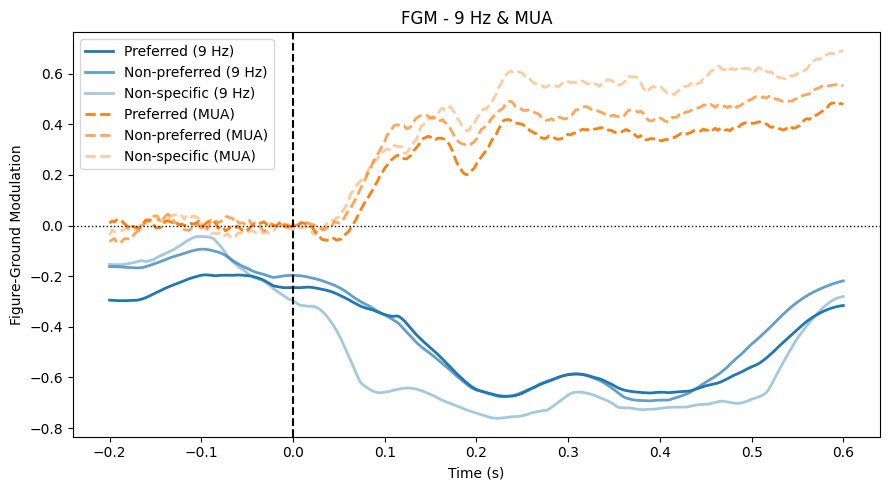

In [28]:
channelsA = np.array([0, 8, 10, 14])
channelsB = np.array([7, 9, 17])
channelsC = np.array([2, 3, 5, 15])
t_vec = np.linspace(-0.2, 0.6, 305)

groups = {
    'A': {
        'channels': channelsA,
        'central_positions': {
            0: np.arange(8, 16),
            1: np.arange(7, 15),
            2: np.arange(8, 16),
            3: np.arange(7, 15),
        }
    },
    'B': {
        'channels': channelsB,
        'central_positions': {
            0: np.arange(8, 16),
            1: np.arange(7, 17),
            2: np.arange(7, 16),
        }
    },
    'C': {
        'channels': channelsC,
        'central_positions': {
            0: np.arange(8, 16),
            1: np.arange(7, 16),
            2: np.arange(7, 15),
        }
    }
}

out_positions = np.array([0, 1, 2, 3, 19, 20, 21, 22])


def smooth_signal(x, window_len=15):
    """Простое скользящее среднее"""
    if window_len < 3:
        return x
    s = np.r_[x[window_len-1:0:-1], x, x[-2:-window_len-1:-1]]
    w = np.ones(window_len)/window_len
    y = np.convolve(s, w, mode='valid')
    return y[(window_len//2):-(window_len//2)]

# частоты для построения
freq_list = [4, -1]  # 3 = 8Hz, -1 = MUA
freq_labels = {4: '9 Hz', -1: 'MUA'}  # подписи для легенды
colors = ['C0', 'C1']  # для графиков двух частот
linestyles = ['-', '--']  # сплошная для f=3, пунктир для last_f=-1

t_mask = slice(None)  # все точки
out_positions = np.array([0, 1, 2, 3, 19, 20, 21, 22])

plt.figure(figsize=(9,5))

for i, last_f in enumerate(freq_list):
    # --- подготовка ---
    fgm_dict = {}
    for grp_name, grp_info in groups.items():
        fgm_45, fgm_135, time_fgm = compute_position_curve_orientation_fgm(
            X_02, y_02,
            X_13, y_13,
            channels=grp_info['channels'],
            last_f=last_f,
            t_mask=t_mask,
            central_positions_dict=grp_info['central_positions'],
            out_positions=out_positions
        )
        # сглаживаем только для MUA (-1)
        if last_f == -1:
            fgm_45 = smooth_signal(fgm_45, window_len=15)
            fgm_135 = smooth_signal(fgm_135, window_len=15)

        fgm_dict[grp_name] = {'45': fgm_45, '135': fgm_135}

    # хитрое усреднение
    pref    = 0.5 * (fgm_dict['A']['135'] + fgm_dict['B']['45'])
    nonpref = 0.5 * (fgm_dict['B']['135'] + fgm_dict['A']['45'])
    nonspes = 0.5 * (fgm_dict['C']['135'] + fgm_dict['C']['45'])

    # построение с понятными подписями
    plt.plot(time_fgm, pref, color=colors[i], lw=2, linestyle=linestyles[i],
             label=f'Preferred ({freq_labels[last_f]})')
    plt.plot(time_fgm, nonpref, color=colors[i], lw=2, linestyle=linestyles[i], alpha=0.7,
             label=f'Non-preferred ({freq_labels[last_f]})')
    plt.plot(time_fgm, nonspes, color=colors[i], lw=2, linestyle=linestyles[i], alpha=0.4,
             label=f'Non-specific ({freq_labels[last_f]})')

plt.axhline(0, color='k', linestyle=':', lw=1)
plt.axvline(0, color='k', linestyle='--', lw=1.5)
plt.xlabel('Time (s)')
plt.ylabel('Figure-Ground Modulation')
plt.title('FGM - 9 Hz & MUA')
plt.legend(loc='upper left', fontsize=10)  # перенос легенды в верхний левый угол
plt.tight_layout()
#plt.savefig("M1V1_FGM_pref_nonprefMUA9hz.png", dpi=600)
plt.show()